In [58]:
# DSI doctoral certificate
# visualization assignment 3
# June 16, 2026, Robert Lu

import numpy as np
import pandas as pd
import re
import requests
import pprint
from datetime import datetime
import os
from pathlib import Path

from pandas.plotting import scatter_matrix

date = datetime.today().strftime("%Y-%m-%d")
print(date)

cwd = os.getcwd()
print(cwd)

2026-06-16
/Users/robertlu/Documents/Biochemistry/DSI/visualization/assignment_3_files


In [ ]:
# below is a function which downloads some data from the City of Toronto
# and saves the files as a csv. 
# based on example code here https://open.toronto.ca/dataset/ttc-bus-delay-data/
# and in other dataset pages

def get_toronto_data_as_csv (id="ttc-bus-delay-data", 
    base_url="https://ckan0.cf.opendata.inter.prod-toronto.ca", save_folder_name = "saved_data",
    date=date):

    """
    Downloads active datasets from the city of toronto

    Find datasets here: https://open.toronto.ca/catalogue/

    The function in its current form downloads ttc delay data as a csv

    Arguments:
        id: string, name of the dataset
        base_url: string, where the data is located. may change based on dataset
        save_folder_name: string, name of folder to save data within current directory
        date: string, the current date
    
    Function code based on example code here https://open.toronto.ca/dataset/ttc-bus-delay-data/

    """

    # The dataset exists as a package
    # apparently "datasets" and "package" is the same thing, package is an older name
    # https://docs.ckan.org/en/latest/user-guide.html
    url = base_url + "/api/3/action/package_show" 
    params = {"id": id}
    package = requests.get(url, params = params).json()

    # To get resource data:
    # within the package (dataset) there are specific datasets, and those datasets have resources
    # the data is accessed by "result", and individual datasets are "resources"
    # like there's some other random info in "result" so we don't need that
    for idx, resource in enumerate(package["result"]["resources"]):

        # for datastore_active resources:
        # check if the dataset is active? For the ttc delay data this is recent data 
        # which can be downloaded as a csv
        if resource["datastore_active"]:
        
            # To get all records in CSV format:
            url = base_url + "/datastore/dump/" + resource["id"]
            resource_dump_data = requests.get(url).text
            #print(resource_dump_data)

            # try to create a separate folder to save the data
            cwd = os.getcwd()
            save_loc = cwd + "/" + save_folder_name
            save_path = Path(cwd, save_folder_name)
            save_path.mkdir(parents=True, exist_ok=True)
            
            # this is here because the ttc delay data has active datasets called "Code Descriptions"
            # which just describes what some codes in their data mean
            # I think the naming is the same for all delay datasets, so create a unique name
            # for each of the code descriptions
            #date = datetime.today().strftime("%Y-%m-%d")
            resource_name = resource["name"].replace(" ", "_")
            if resource_name == "Code_Descriptions":
                csv_name = save_loc + "/" + date + "_" + params["id"] + "_" + resource_name + ".csv"
            else:
                csv_name = save_loc + "/" + date + "_" + resource_name + ".csv"

            # save the data as a csv file
            with open(csv_name, "w", encoding="utf-8") as file:
                file.write(resource_dump_data)


            # other demo code below which I kept just in case 
            
            # To selectively pull records and attribute-level metadata:
            url = base_url + "/api/3/action/datastore_search"
            p = { "id": resource["id"] }
            resource_search_data = requests.get(url, params = p).json()["result"]
            #print(resource_search_data)
            # This API call has many parameters. They're documented here:
            # https://docs.ckan.org/en/latest/maintaining/datastore.html
    
        # To get metadata for non datastore_active resources:
        if not resource["datastore_active"]:
            url = base_url + "/api/3/action/resource_show?id=" + resource["id"]
            resource_metadata = requests.get(url).json()
            #print(resource_metadata)
            # From here, you can use the "url" attribute to download this file

In [ ]:
# download the relevant data
# This functions works for the delay datasets
# might not work for other datasets

get_toronto_data_as_csv("ttc-bus-delay-data")
get_toronto_data_as_csv("ttc-streetcar-delay-data")
get_toronto_data_as_csv("ttc-subway-delay-data")
get_toronto_data_as_csv("ttc-lrt-delay-data")

# takes about 12 sec to run

In [42]:
# read the data
# just look up the saved file names from earlier and type them
# because the data download can be performed on multiple days
# or the resource names from the ttc source can change,
# just use data downloaded on June 16 so that the data is consistent just for plotting purposes

df_bus = pd.read_csv("./saved_data/2026-06-16_TTC_Bus_Delay_Data_since_2025.csv")
df_streetcar = pd.read_csv("./saved_data/2026-06-16_TTC_Streetcar_Delay_Data_since_2025.csv")
df_subway = pd.read_csv("./saved_data/2026-06-16_TTC_Subway_Delay_Data_since_2025.csv")
df_lrt = pd.read_csv("./saved_data/2026-06-16_TTC_LRT_Delays.csv")

In [43]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84145 entries, 0 to 84144
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   _id        84145 non-null  int64 
 1   Date       84145 non-null  object
 2   Line       83143 non-null  object
 3   Time       84145 non-null  object
 4   Day        84145 non-null  object
 5   Station    84145 non-null  object
 6   Code       84145 non-null  object
 7   Min Delay  84145 non-null  int64 
 8   Min Gap    84145 non-null  int64 
 9   Bound      67550 non-null  object
 10  Vehicle    84145 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 7.1+ MB


In [63]:
df_bus["Line"].value_counts().reset_index().head(20)

,Line,count
0,52 LAWRENCE WEST,2005
1,32 EGLINTON WEST,2001
2,29 DUFFERIN,1614
3,102 MARKHAM ROAD,1599
4,7 BATHURST,1523
5,939 FINCH EXPRESS,1432
6,54 LAWRENCE EAST,1379
7,36 FINCH WEST,1366
8,63 OSSINGTON,1337
9,116 MORNINGSIDE,1277


In [84]:
df_bus["Line"].unique()

array(['102 MARKHAM ROAD', '65 PARLIAMENT', '64 MAIN',
       '100 FLEMINGDON PARK', '34 EGLINTON EAST', '320 YONGE',
       '307 BATHURST', '112 WEST MALL', '39 FINCH EAST', '35 JANE',
       '19 BAY', '22 COXWELL', '36 FINCH WEST', '12 KINGSTON ROAD',
       '7 BATHURST', '86 SCARBOROUGH', '929 DUFFERIN EXPRESS',
       '927 HIGHWAY 27 EXPRESS', '80 QUEENSWAY', '939 FINCH EXPRESS',
       '41 KEELE', '935 JANE EXPRESS', '8 BROADVIEW', '84 SHEPPARD WEST',
       '122 GRAYDON HALL', '16 MCCOWAN', '96 WILSON', '85 SHEPPARD EAST',
       '900 AIRPORT ROCKET', '123 SHERWAY', '95 YORK MILLS',
       '129 MCCOWAN NORTH', '54 LAWRENCE EAST', '161 ROGERS ROAD',
       '51 LESLIE', '94 WELLESLEY', '160 BATHURST NORTH',
       '110 ISLINGTON SOUTH', '21 BRIMLEY', nan, '83 JONES',
       '29 DUFFERIN', '24 VICTORIA PARK', '75 SHERBOURNE', '72 PAPE',
       '116 MORNINGSIDE', '52 LAWRENCE WEST', '97 YONGE', '133 NEILSON',
       '17 BIRCHMOUNT', '87 COSBURN', '107 YORK UNIVERSITY HE',
       '334

In [74]:
df_streetcar[df_streetcar["Line"].str.contains("504", na=False)]

,_id,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle
0,1,2025-01-01,504 KING,02:10,Wednesday,KING AND PARLIAMENT,MTSAN,10,20,W,4569
2,3,2025-01-01,504 KING,03:11,Wednesday,KING AND QUEEN EAST,MTIE,15,30,E,4629
4,5,2025-01-01,504 KING,06:14,Wednesday,LESLIE CARHOUSE,MTVIS,10,20,E,4483
5,6,2025-01-01,504 KING,09:02,Wednesday,KING AND JAMESON,MTUIR,10,20,W,4606
10,11,2025-01-01,504 KING,15:04,Wednesday,RONCESVALLES AND HOWAR,MTSAN,10,20,N,4556
...,...,...,...,...,...,...,...,...,...,...,...
19419,19420,2026-04-30,504 KING,10:07,Thursday,BROADVIEW AND DANFORTH,MFSH,10,20,N,8905
19421,19422,2026-04-30,504 KING,10:09,Thursday,BRAODVIEW STATION,MFSH,10,20,N,8627
19424,19425,2026-04-30,504 KING,10:52,Thursday,KINGSTON LOOP,STL,0,0,NaN,4497
19425,19426,2026-04-30,504 KING,12:20,Thursday,KING AND ONTARIO,MTSAN,10,20,NaN,4663


In [116]:
df_streetcar["Day"].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday'], dtype=object)

In [57]:
for i, item in enumerate(df_streetcar["Line"].tolist()):
    if re.search("504", str(item)):
        print(i, str(item))

0 504 KING
2 504 KING
4 504 KING
5 504 KING
10 504 KING
18 504 KING
21 504 KING
24 504 KING
43 504 KING
44 504 KING
45 504 KING
48 504 KING
63 504 KING
74 504 KING
79 504 KING
80 504 KING
93 504 KING
101 504 KING
116 504 KING
117 504 KING
121 504 KING
129 504 KING
131 504 KING
133 504 KING
134 504 KING
138 504 KING
149 504 KING
151 504 KING
154 504 KING
165 504 KING
168 504 KING
181 504 KING
183 504 KING
184 504 KING
221 504 KING
235 504 KING
239 504 KING
258 504 KING
259 504 KING
276 504 KING
288 504 KING
292 504 KING
305 504 KING
306 504 KING
309 504 KING
311 504 KING
312 504 KING
316 504 KING
319 504 KING
326 504 KING
330 504 KING
336 504 KING
339 504 KING
355 504 KING
356 504 KING
365 504 KING
372 504 KING
379 504 KING
380 504 KING
382 504 KING
407 504 KING
445 504 KING
470 504 KING
480 504 KING
492 504 KING RAD CAR
504 504 KING
512 504 KING
528 504 KING
540 504 KING
547 504 KING
555 504 KING
567 504 KING
576 504 KING
577 504 KING
586 504 KING
588 504 KING
592 504 KING
594 504 KING

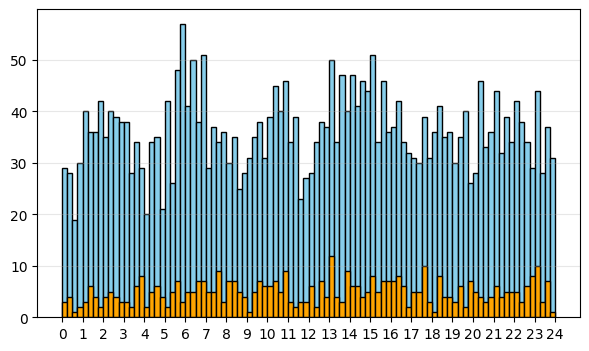

In [141]:
# Given the data and my available time, what data would be interesting to show?
# I think the biggest limiting factor is that I don't know if overall trip number 
# data is available. The delay data shows only the delays, but I think it's more
# useful to look at delays as a fraction of total trips. 
# Without data on non-delayed trips, then this limits what the plot shows to 
# "If there's a delay, then here are some features of the delay"

# I was gonna make an interactive plot based on https://plotly.com/python/figurewidget-app/
# but there's some modules missing within the environment, so I can't use those
# Guess I'll just make a static plot

# For all delays on the 504 King Streetcar and 503 Kingston Bus,
# what is the time distribution of the delays by time of day and by weekday?

weekday = "Tuesday"

# get data by weekday
df_504_weekday = df_streetcar[(df_streetcar["Day"] == weekday) & (df_streetcar["Line"].str.contains("504", na=False))]
df_503_weekday = df_bus[(df_bus["Day"] == weekday) & (df_bus["Line"].str.contains("503", na=False))]

# all data
df_504 = df_streetcar[df_streetcar["Line"].str.contains("504", na=False)]
df_503 = df_bus[df_bus["Line"].str.contains("503", na=False)]

# get the time data in decimal format
times_504_weekday = pd.to_datetime(df_504_weekday["Time"].values, format="%H:%M")
times_decimal_504_weekday = [t.hour + t.minute/60 for t in times_504_weekday]
times_503_weekday = pd.to_datetime(df_503_weekday["Time"].values, format="%H:%M")
times_decimal_503_weekday = [t.hour + t.minute/60 for t in times_503_weekday]

times_504 = pd.to_datetime(df_504["Time"].values, format="%H:%M")
times_decimal_504 = [t.hour + t.minute/60 for t in times_504]
times_503 = pd.to_datetime(df_503["Time"].values, format="%H:%M")
times_decimal_503 = [t.hour + t.minute/60 for t in times_503]

# create a histogram with bins every 15 minutes
# 24 hrs, 4 bins/hour, 96 bins total

bins = np.arange(0, 24.01, 0.25)

# Plot the histogram
plt.figure(figsize=(7, 4))
plt.hist(times_decimal_504, bins=bins, edgecolor='black', color='skyblue')
plt.hist(times_decimal_504_weekday, bins=bins, edgecolor='black', color='orange')

# 5. Format X-axis to show clear hourly intervals
plt.xticks(range(0, 25, 1)) 
#plt.xlabel('Hour of the Day')
#plt.ylabel('Frequency of Events')
#plt.title('Event Occurrences by Time of Day')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [140]:
bins

array([ 0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,
        2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,
        4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,
        6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,
        9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 , 10.75, 11.  ,
       11.25, 11.5 , 11.75, 12.  , 12.25, 12.5 , 12.75, 13.  , 13.25,
       13.5 , 13.75, 14.  , 14.25, 14.5 , 14.75, 15.  , 15.25, 15.5 ,
       15.75, 16.  , 16.25, 16.5 , 16.75, 17.  , 17.25, 17.5 , 17.75,
       18.  , 18.25, 18.5 , 18.75, 19.  , 19.25, 19.5 , 19.75, 20.  ,
       20.25, 20.5 , 20.75, 21.  , 21.25, 21.5 , 21.75, 22.  , 22.25,
       22.5 , 22.75, 23.  , 23.25, 23.5 , 23.75, 24.  ])

In [133]:
times_504

DatetimeIndex(['1900-01-01 02:10:00', '1900-01-01 03:11:00',
               '1900-01-01 06:14:00', '1900-01-01 09:02:00',
               '1900-01-01 15:04:00', '1900-01-01 22:46:00',
               '1900-01-01 03:27:00', '1900-01-01 05:04:00',
               '1900-01-01 13:36:00', '1900-01-01 13:39:00',
               ...
               '1900-01-01 03:52:00', '1900-01-01 04:25:00',
               '1900-01-01 04:40:00', '1900-01-01 06:51:00',
               '1900-01-01 06:51:00', '1900-01-01 10:07:00',
               '1900-01-01 10:09:00', '1900-01-01 10:52:00',
               '1900-01-01 12:20:00', '1900-01-01 19:37:00'],
              dtype='datetime64[ns]', length=3469, freq=None)

In [109]:
times = pd.to_datetime(df_504["Time"].values, format="%H:%M")
times[0]

Timestamp('1900-01-01 02:10:00')

In [110]:
times[0].hour

2

In [111]:
times[0].minute

10

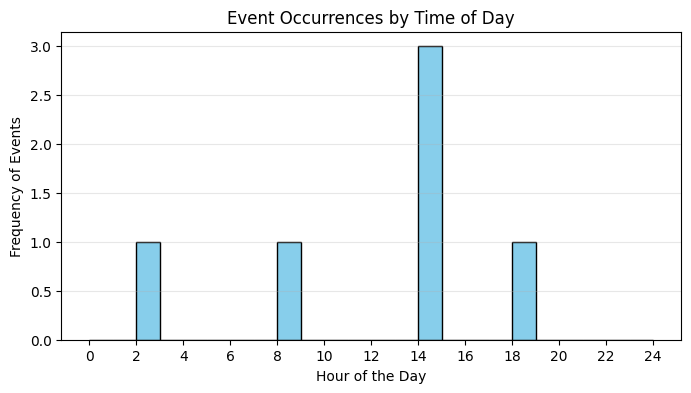

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data: Timestamps of various events
data = np.array(['08:30', '14:25', '14:40', '18:15', '02:10', '14:05'])

# 1. Convert to pandas datetime objects
times = pd.to_datetime(data, format="%H:%M")

# 2. Extract the hour component
hours = [t.hour for t in times]

# 3. Define bins for every hour of the day (0 to 24)
bins = range(0, 25)

# 4. Plot the histogram
plt.figure(figsize=(8, 4))
plt.hist(hours, bins=bins, edgecolor='black', color='skyblue')

# 5. Format X-axis to show clear hourly intervals
plt.xticks(range(0, 25, 2)) 
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency of Events')
plt.title('Event Occurrences by Time of Day')
plt.grid(axis='y', alpha=0.3)

plt.show()

